## Data Analysis and Visualization

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
%matplotlib inline

In [7]:
train = pd.read_csv("../data/processed/processed_train.csv")

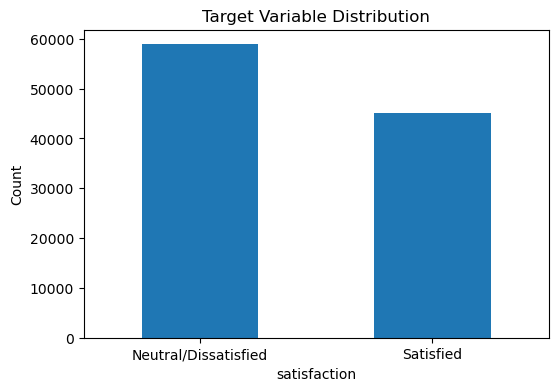

Class balance:
satisfaction
0    0.566667
1    0.433333
Name: proportion, dtype: float64


In [8]:
# target variable distribution
fig, ax = plt.subplots(figsize=(6, 4))
train["satisfaction"].value_counts().plot(kind="bar", ax=ax)
ax.set_xticklabels(["Neutral/Dissatisfied", "Satisfied"], rotation=0)
ax.set_title("Target Variable Distribution")
ax.set_ylabel("Count")
plt.show()

print("Class balance:")
print(train["satisfaction"].value_counts(normalize=True))

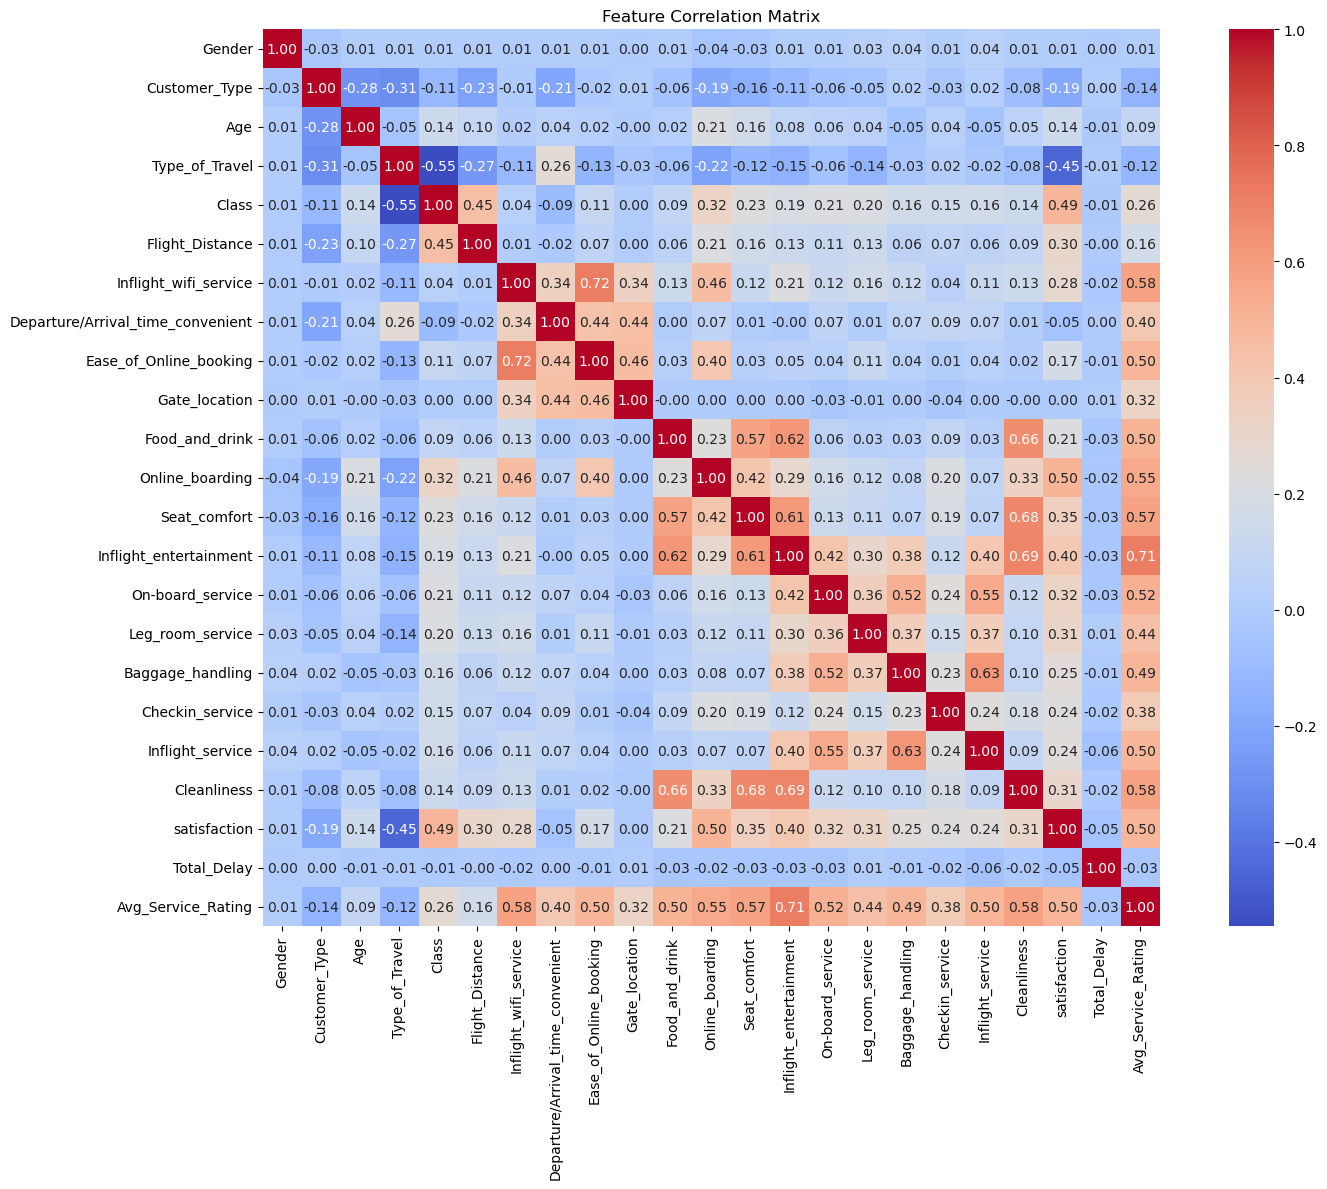

In [9]:
# correlation heatmap
plt.figure(figsize=(16, 12))
corrmat = train.corr()
sns.heatmap(corrmat, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

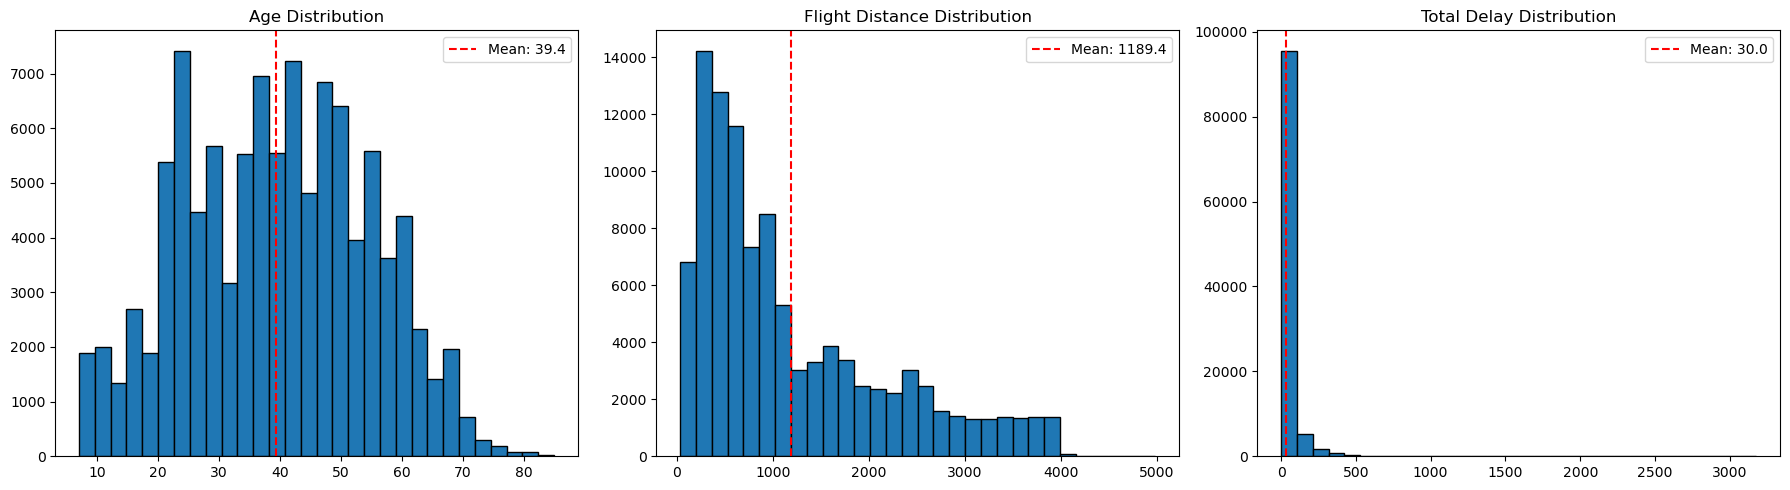

In [10]:
# distribution of continuous features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(train["Age"], bins=30, edgecolor="black")
axes[0].set_title("Age Distribution")
axes[0].axvline(train["Age"].mean(), color="red", linestyle="--", label=f'Mean: {train["Age"].mean():.1f}')
axes[0].legend()

axes[1].hist(train["Flight_Distance"], bins=30, edgecolor="black")
axes[1].set_title("Flight Distance Distribution")
axes[1].axvline(train["Flight_Distance"].mean(), color="red", linestyle="--", label=f'Mean: {train["Flight_Distance"].mean():.1f}')
axes[1].legend()

axes[2].hist(train["Total_Delay"], bins=30, edgecolor="black")
axes[2].set_title("Total Delay Distribution")
axes[2].axvline(train["Total_Delay"].mean(), color="red", linestyle="--", label=f'Mean: {train["Total_Delay"].mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

__Age__: Bimodal with one peak at around 25 and another at around 42, evenly distributed across adult ages with a dip on either end

__Flight Distance__: heavily right skewed with majority of flights being short haul but a clear tail up to 4000 miles, the mean is being pulled by those longer haul flights

__Total Delay__ : right skewed with the vast majority of passenfers experiencing little to no delay with a few cases going up to 500+ minutes

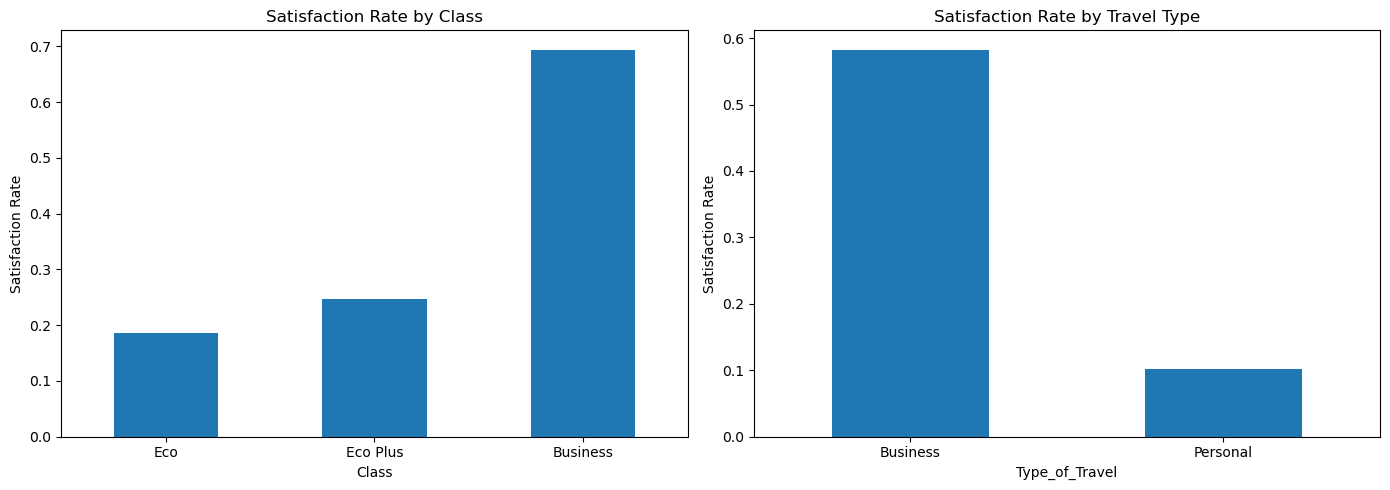

In [11]:
# satisfaction rate by class and travel type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train.groupby("Class")["satisfaction"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Satisfaction Rate by Class")
axes[0].set_xticklabels(["Eco", "Eco Plus", "Business"], rotation=0)
axes[0].set_ylabel("Satisfaction Rate")

train.groupby("Type_of_Travel")["satisfaction"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Satisfaction Rate by Travel Type")
axes[1].set_xticklabels(["Business", "Personal"], rotation=0)
axes[1].set_ylabel("Satisfaction Rate")

plt.tight_layout()
plt.show()

__Satisfaction by class__ : Buisness class passengers are satisfied approximately 70% of the time while Eco plus is 25% and Eco is approximately 20%, Buisness class passengers are 3 times more likely to be satisfied. This makes sense considering more leg room, better food and service in buisness class.

__Satisfaction by travel type__: Buissness travelers are satisfied approximately 60% of the time while personal travelers only 10%. this drastic difference could be explained by buisness travlers being more used to travel conditions as well as possible loyalty perks.

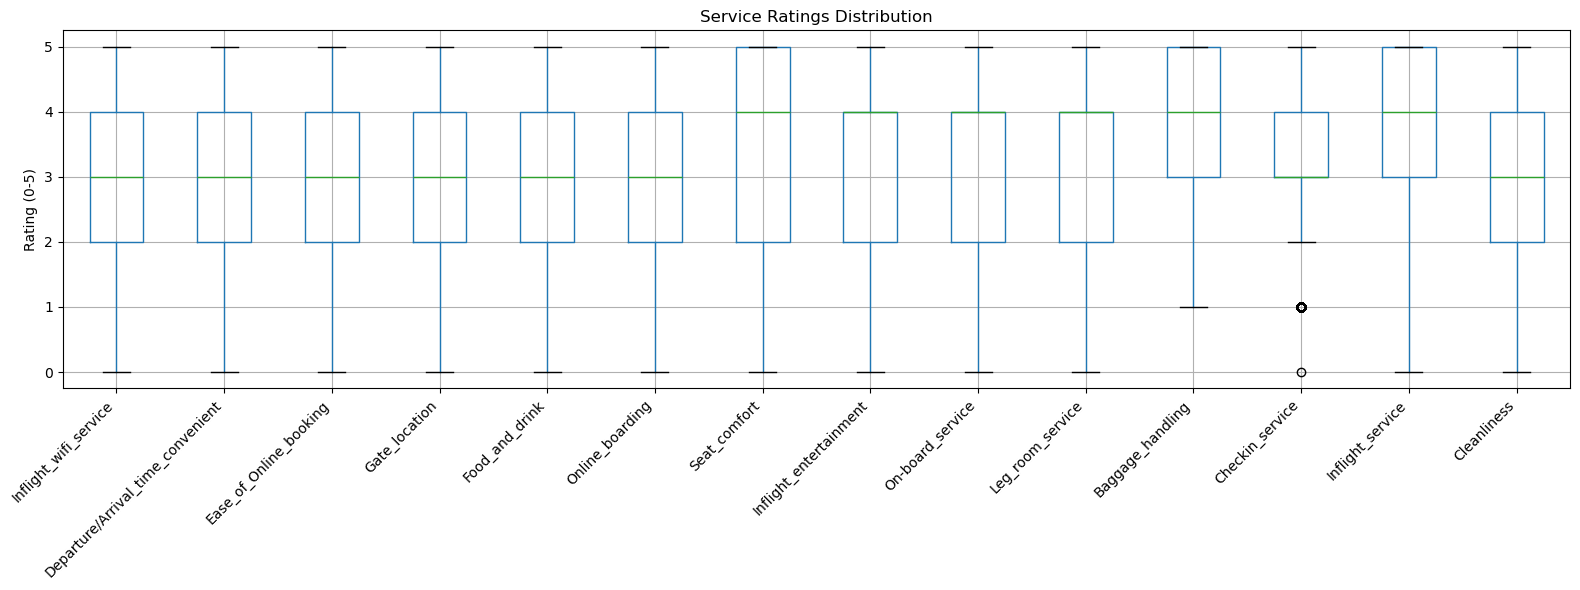

In [12]:
# service ratings boxplot
service_cols = ["Inflight_wifi_service", "Departure/Arrival_time_convenient",
                "Ease_of_Online_booking", "Gate_location", "Food_and_drink",
                "Online_boarding", "Seat_comfort", "Inflight_entertainment",
                "On-board_service", "Leg_room_service", "Baggage_handling",
                "Checkin_service", "Inflight_service", "Cleanliness"]

plt.figure(figsize=(16, 6))
train[service_cols].boxplot()
plt.xticks(rotation=45, ha="right")
plt.title("Service Ratings Distribution")
plt.ylabel("Rating (0-5)")
plt.tight_layout()
plt.show()

Most services appear to have a median of 3 with the box spanning 2-4, passengers generally rate them average with expected spread with a few features standing out

__Higher rated services__ : Baggage_handling, Inflight_service, and Checkin_service have medians around 3–4 with tighter boxes pushed higher. Checkin service and inflight service are two of the higher rated services with outliers at 0 and 1, could be possible anomalies considering majority rating

__0 rating__ : Possible consideration is that the 0 rating could be a result of unused services these could skew models if they arent pure data points